# 103 - RichData, Plotting, and IO Basics

Most of prysm is ordinary functions, but some of the parts of the library
you will work with most are oriented around a single class, e.g.
`propagation.Wavefront` or `interferogram.Interferogram`.  The latter is
a subclass of `RichData`, and the former has attributes that return `RichData`s,
and is only not a RichData itself because the complex array at its core is not
generally plottable.

RichData is simply a container that stores:
- `.data`, the 2D array of data
- `.dx` - the sample spacing
- `{.x, .y, .r, .t}` the coordinate grids over which data exists.

The grids are dynamically computed from `.dx` when needed, which is rare.
There is a minor sharp edge on rare occasion when you compute something
in an off-center grid, then the grids are generated centered and your
program has gotten out of sync with itself.  In practical application,
this is almost never a problem.

In the rest of this notebook, we'll walk through `RichData`, `Slices`, and
a little bit of I/O.  As always, we start with a couple of imports:

In [2]:
import numpy as np
from matplotlib import pyplot as plt

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.geometry import circle
from prysm.polynomials import zernike_nm
from prysm.interferogram import Interferogram

## Making RichData

You will almost never make your own `RichData`.  We'll construct an
Interferogram from scratch, which is a subclass:

In [4]:
D = 50
x, y = make_xy_grid(256, diameter=D)
r, t = cart_to_polar(x, y)
dx = x[0,1] - x[0,0]
rho = r / (D/2)

phase_nm = 120 * zernike_nm(2, 2, rho, t) + 60 * zernike_nm(3, 1, rho, t)

interf = Interferogram(phase=phase_nm, dx=dx, wavelength=0.6328)

## RichData attributes

- `.shape` and `.size` pass through to `.data.shape` and `.data.size`; size = total # of elements
- `.x, .y, .r, .t`
- `.support_x`, `.support_y`, `.support` - physical extent (may change in the future to be .extent to mimic matplotlib)

In [6]:
print('shape     ', interf.shape)
print('dx        ', round(interf.dx, 4), 'mm')
print('support   ', round(interf.support, 2), 'mm')
print('x grid    ', interf.x.shape, 'spanning', round(float(interf.x.min()), 2), 'to', round(float(interf.x.max()), 2), 'mm')

shape      (256, 256)
dx         0.1953 mm
support    50.0 mm
x grid     (256, 256) spanning -25.0 to 24.8 mm


In [4]:
print('PV  =', round(ifgm.pv, 1), 'nm')
print('RMS =', round(ifgm.rms, 1), 'nm')
print('Sa  =', round(ifgm.Sa, 1), 'nm')

PV  = 1339.9 nm
RMS = 186.3 nm
Sa  = 142.6 nm


## Plotting

`RichData` is plottable in both 2D and 1D:

- `.plot2d()`
- `slices().plot()`

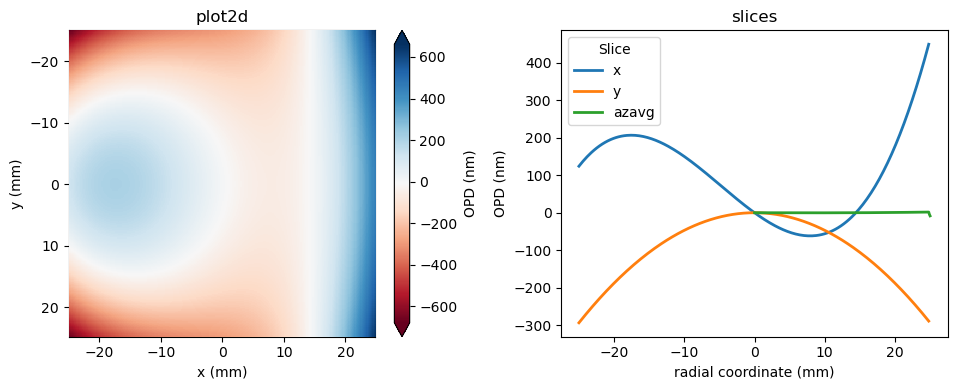

In [13]:
fig, axs = plt.subplots(ncols=2, figsize=(10,4))
interf.plot2d(cmap='RdBu', interpolation='nearest',
            colorbar_label='OPD (nm)', axis_labels=('x (mm)', 'y (mm)'),
            fig=fig, ax=axs[0])
axs[0].set(title='plot2d')

interf.slices().plot(['x', 'y', 'azavg'], fig=fig, ax=axs[1])
axs[1].set(title='slices', xlabel='radial coordinate (mm)', ylabel='OPD (nm)')
fig.tight_layout();

## NaNs and masking

RichData is completely NaN-aware.  You should use NaN to mark invalid
pixels instead of setting them to a valid value such as 0, which would
corrupt statistics:

fraction valid: 0.785
RMS over the aperture: 134.0 nm  (NaNs ignored)


(<Figure size 640x480 with 2 Axes>, <Axes: >)

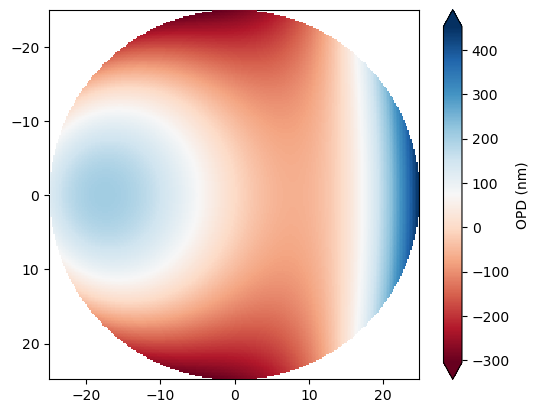

In [14]:
mask = circle(1, rho)                # 1 inside the 25 mm radius, 0 outside
masked = phase_nm.copy()
masked[mask != 1] = np.nan          # invalid outside the aperture

imasked = Interferogram(phase=masked, dx=50.0/256, wavelength=0.6328)
print('fraction valid:', round(np.isfinite(imasked.data).mean(), 3))
print('RMS over the aperture:', round(imasked.rms, 1), 'nm  (NaNs ignored)')

imasked.plot2d(cmap='RdBu', interpolation='nearest', colorbar_label='OPD (nm)')

## Wrap Up

In this notebook we walked through RichData and Slices, the two foundational classes for visually interacting with data and the most common container for a 2D array.  The final notebook in the foundational college will walk through changing the computational backend and reduced precision calculations for faster performance, especially on GPUs, and reduced memory usage.

In [7]:
import tempfile, os
path = os.path.join(tempfile.gettempdir(), 'foundations_demo.dat')

ifgm.save_zygo_dat(path)                       # write
reloaded = Interferogram.from_zygo_dat(path)   # read

print('shape preserved:', reloaded.shape == ifgm.shape)
print('RMS  original :', round(ifgm.rms, 2), 'nm')
print('RMS  reloaded :', round(reloaded.rms, 2), 'nm')

shape preserved: True
RMS  original : 186.28 nm
RMS  reloaded : 186.28 nm


The same module reads and writes the other formats you are likely to meet:

- `io.read_zygo_datx` - the newer HDF5-based Zygo format (needs `h5py`)
- `io.read_codev_gridint` / `io.write_codev_gridint` - Code V grid (INT) files
- `io.read_zygo_dat` / `io.write_zygo_dat` - the raw dict-level readers, if you
  want the metadata and intensity frames without an `Interferogram` wrapper

That is the whole Foundations data path: build coordinates (102), wrap an array
and its `dx` in a `RichData` (here), and read or write it with `prysm.io`.  The
last Foundations notebook, 104, covers the numerical knobs underneath all of it:
floating-point precision and the array backend.